# Visualizing Field Line Geometry (`mageometry.viz`)

`mageometry.viz` draws the objects the analysis API already produces — a `field(x, y, z)` callable, a `FieldLineTrace`, coordinates — with matplotlib. Every function takes an optional `ax` (2D or 3D), returns the matplotlib artists, and labels axes in the field's own length unit (`unit=`). Undefined values (NaN from the geometry functions) are left blank.

Requires matplotlib (`pip install matplotlib` or `pip install -e .[viz]`).

## Contents

1. [Setup](#setup)
2. [Maps of geometry quantities on a plane](#maps)
3. [Traced field lines, coloured by a quantity](#lines)
4. [Profiles along field lines](#profiles)
5. [Frenet frames](#frames)
6. [Composing figures and custom quantities](#compose)
7. [The same plots on simulation data](#simdata)

In [1]:
from datetime import datetime, timezone

import numpy as np
import matplotlib.pyplot as plt

from mageometry import geopack, geopack_field, trace_field_lines, GriddedField
from mageometry import viz

%matplotlib inline

ut = datetime(2023, 3, 15, 12, 0, 0, tzinfo=timezone.utc).timestamp()
ps = geopack.recalc(ut)
parmod = [2.0, -20.0, 0.0, -5.0, 0, 0, 0, 0, 0, 0]
field = geopack_field("t96", "dip", parmod, ps)
earth = lambda x, y, z: x * x + y * y + z * z < 1.0     # mask for the planet

<a id="setup"></a>
## 1. Setup

The field is T96 + dipole; `earth` is a mask callable used to blank the planet in maps. Named quantities available to all plotting functions:

In [2]:
for name, q in viz.QUANTITIES.items():
    print(f"{name:14s} {q.label:22s} {'log' if q.log else ('signed' if q.symmetric else 'linear')}")

curvature      curvature κ            log
torsion        torsion τ              signed
frame_quality  cos θ (frame quality)  log
bmag           |B|                    log
bx             Bx                     signed
by             By                     signed
bz             Bz                     signed
dT_dT_n        (∂T/∂T)·n              linear
dT_dT_b        (∂T/∂T)·b              signed
dn_dT_b        (∂n/∂T)·b              signed
dn_dT_T        (∂n/∂T)·T              signed
db_dT_T        (∂b/∂T)·T              signed
db_dT_n        (∂b/∂T)·n              signed
dT_dn_n        (∂T/∂n)·n              signed
dT_dn_b        (∂T/∂n)·b              signed
dn_dn_b        (∂n/∂n)·b              signed
dn_dn_T        (∂n/∂n)·T              signed
db_dn_T        (∂b/∂n)·T              signed
db_dn_n        (∂b/∂n)·n              signed
dn_db_b        (∂n/∂b)·b              signed
dn_db_T        (∂n/∂b)·T              signed
db_db_T        (∂b/∂b)·T              signed
db_db_n        (∂b/

<a id="maps"></a>
## 2. Maps of geometry quantities on a plane

`plot_geometry_map(field, quantity, plane, extent, n, ...)` samples the plane, evaluates the quantity, and draws it with a colour scale that follows the quantity's convention: log for curvature, |B|, and the frame-quality diagnostic; diverging and symmetric about zero for signed quantities such as torsion or the directional derivatives. `arrows=True` overlays the in-plane field direction.

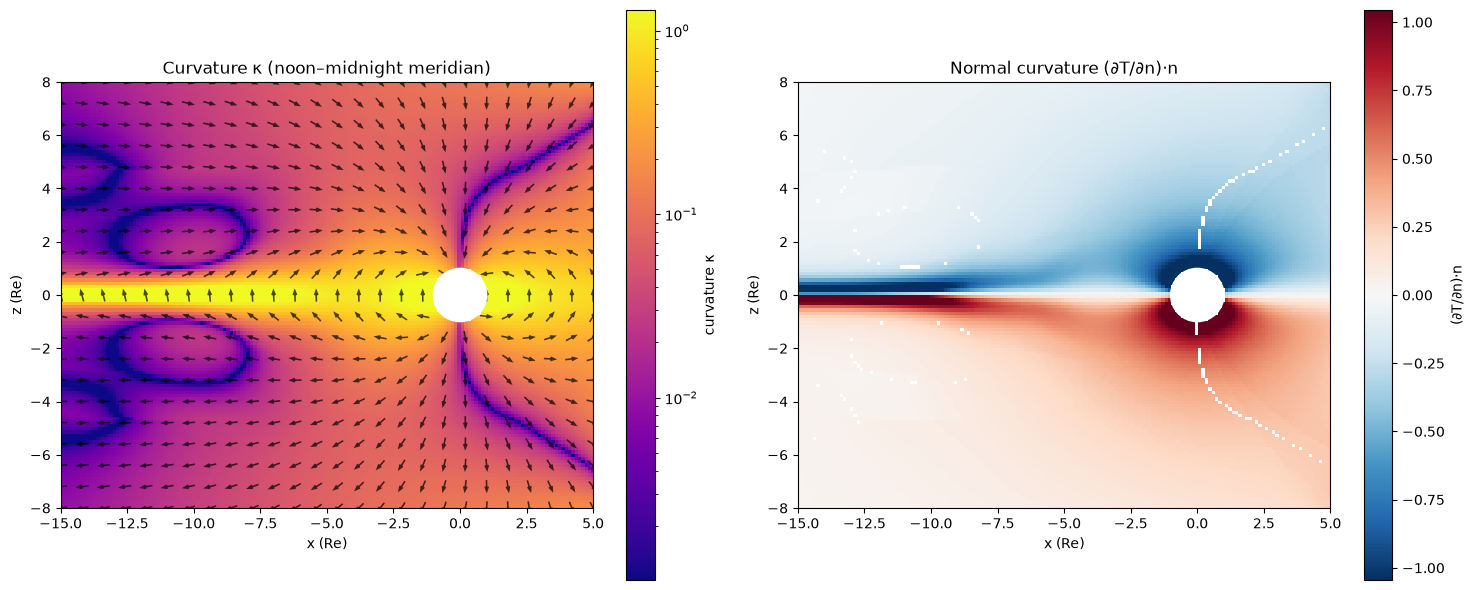

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
viz.plot_geometry_map(field, "curvature", plane="xz", extent=(-15, 5, -8, 8), n=(160, 130),
                      mask=earth, arrows=True, ax=axes[0], unit="Re")
viz.plot_geometry_map(field, "dT_dn_n", plane="xz", extent=(-15, 5, -8, 8), n=(160, 130),
                      mask=earth, ax=axes[1], unit="Re")
for ax in axes:
    ax.add_patch(plt.Circle((0, 0), 1, color="white", zorder=10))
axes[0].set_title("Curvature κ (noon–midnight meridian)")
axes[1].set_title("Normal curvature (∂T/∂n)·n")
plt.tight_layout()
plt.show()

The thin blank curves in the right panel are where the principal normal flips across an inflection of the field line — the directional derivatives are undefined there and come back as NaN, which the map leaves blank instead of painting a spurious value.

Any plane works (`'xy'`, `'yz'`, or reversed letter order to swap the axes) and `offset` moves it along its normal:

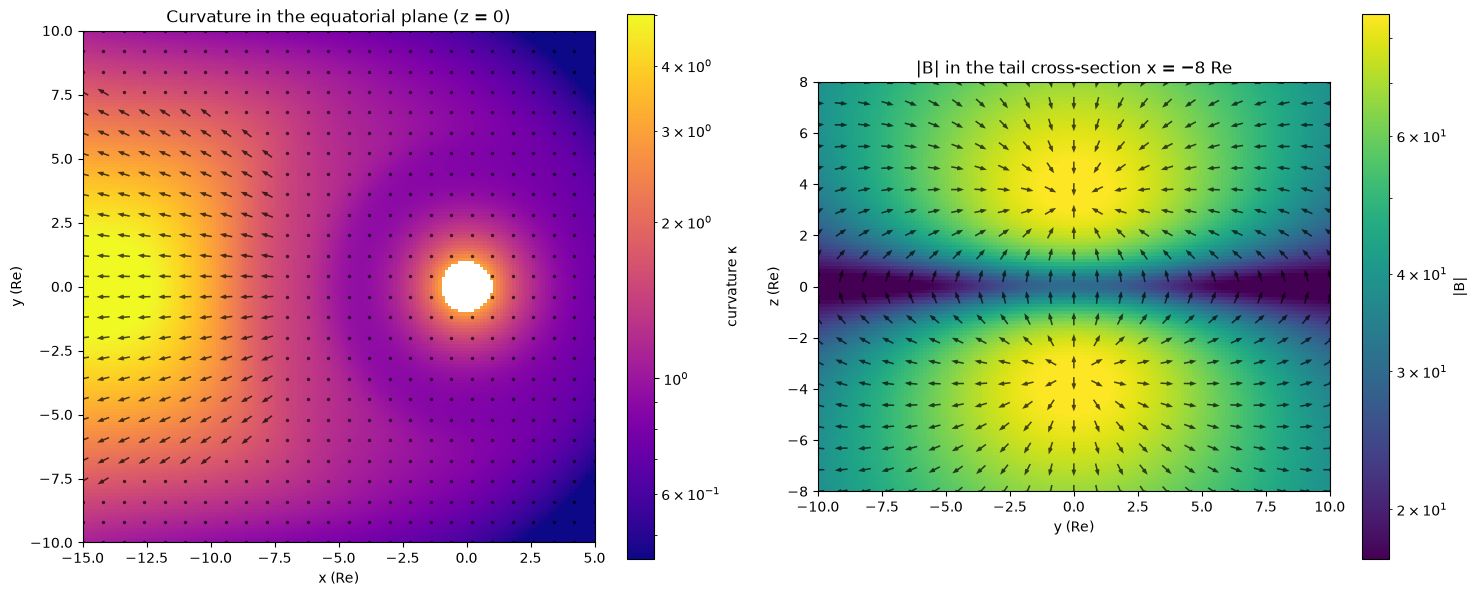

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
viz.plot_geometry_map(field, "curvature", plane="xy", extent=(-15, 5, -10, 10), n=(160, 160),
                      mask=earth, arrows=True, ax=axes[0], unit="Re")
viz.plot_geometry_map(field, "bmag", plane="yz", offset=-8.0, extent=(-10, 10, -8, 8), n=(140, 120),
                      arrows=True, ax=axes[1], unit="Re")
axes[0].set_title("Curvature in the equatorial plane (z = 0)")
axes[1].set_title("|B| in the tail cross-section x = −8 Re")
plt.tight_layout()
plt.show()

<a id="lines"></a>
## 3. Traced field lines, coloured by a quantity

`plot_field_lines(trace, ...)` draws a `FieldLineTrace` projected onto a plane, or in 3D when given a 3D axes. `color=` accepts a plain colour, a quantity name (with `field=`), a callable, or an array of values along the paths.

FieldLineTrace(n_lines=6, max_points=195, status={'inner': 6})


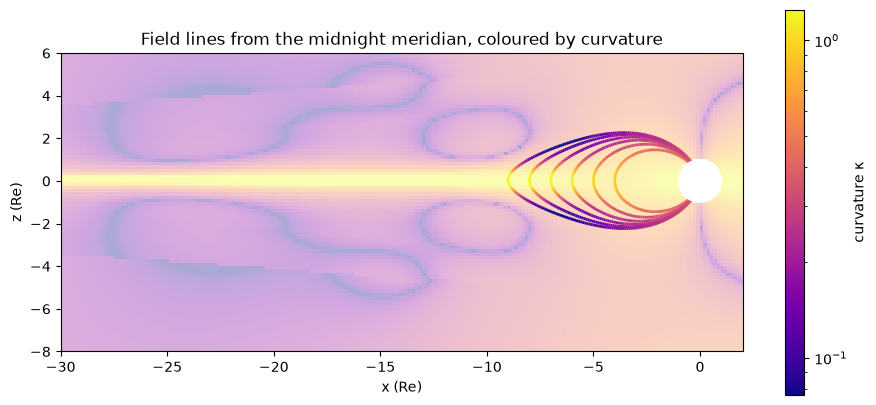

In [5]:
seeds = np.array([-4.0, -5.0, -6.0, -7.0, -8.0, -9.0])
tr = trace_field_lines(field, seeds, np.zeros_like(seeds), np.zeros_like(seeds),
                       direction="both", ds=0.1, r0=1.0, rlim=30.0)
print(tr)

fig, ax = plt.subplots(figsize=(11, 5))
viz.plot_geometry_map(field, "curvature", plane="xz", extent=(-30, 2, -8, 6), n=(200, 90),
                      mask=earth, ax=ax, unit="Re", alpha=0.35, colorbar=False)
viz.plot_field_lines(tr, plane="xz", color="curvature", field=field, ax=ax, unit="Re", linewidth=2)
ax.add_patch(plt.Circle((0, 0), 1, color="white", zorder=10))
ax.set_title("Field lines from the midnight meridian, coloured by curvature")
plt.show()

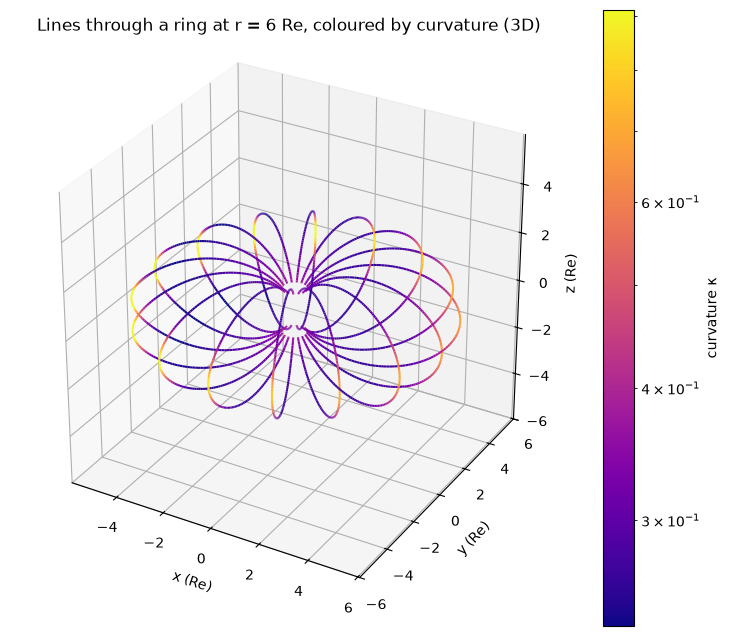

In [6]:
phi = np.linspace(0, 2 * np.pi, 16, endpoint=False)
ring = trace_field_lines(field, 6 * np.cos(phi), 6 * np.sin(phi), np.zeros_like(phi),
                         direction="both", ds=0.1, r0=1.0, rlim=25.0)

fig = plt.figure(figsize=(9, 8))
ax3 = fig.add_subplot(111, projection="3d")
viz.plot_field_lines(ring, ax=ax3, color="curvature", field=field, unit="Re", linewidth=1.5)
ax3.set_title("Lines through a ring at r = 6 Re, coloured by curvature (3D)")
plt.show()

<a id="profiles"></a>
## 4. Profiles along field lines

`plot_line_profiles(trace, field, quantities)` evaluates quantities on each traced path and plots them against the arc length `s` from the seed (signed for `direction='both'`).

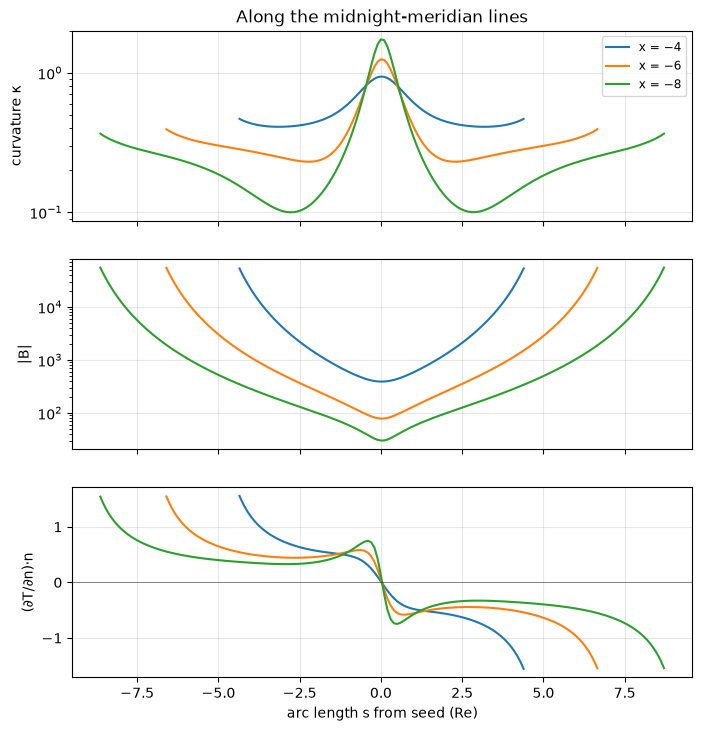

In [7]:
axes = viz.plot_line_profiles(tr, field, ("curvature", "bmag", "dT_dn_n"), lines=[0, 2, 4],
                              labels=["x = −4", "x = −6", "x = −8"], unit="Re")
axes[0].set_title("Along the midnight-meridian lines")
plt.show()

Curvature peaks at the equatorial crossing of each line (s = 0; note the log scale), falls to a minimum where the line is straightest on its way out of the current-sheet region, then rises again toward the planet where the dipole's 3/r curvature takes over. The normal curvature (∂T/∂n)·n changes sign across the equator.

<a id="frames"></a>
## 5. Frenet frames

`plot_frenet_frame(field, x, y, z)` draws **T** (red), **n** (green), **b** (blue) at points, in 2D projection or 3D.

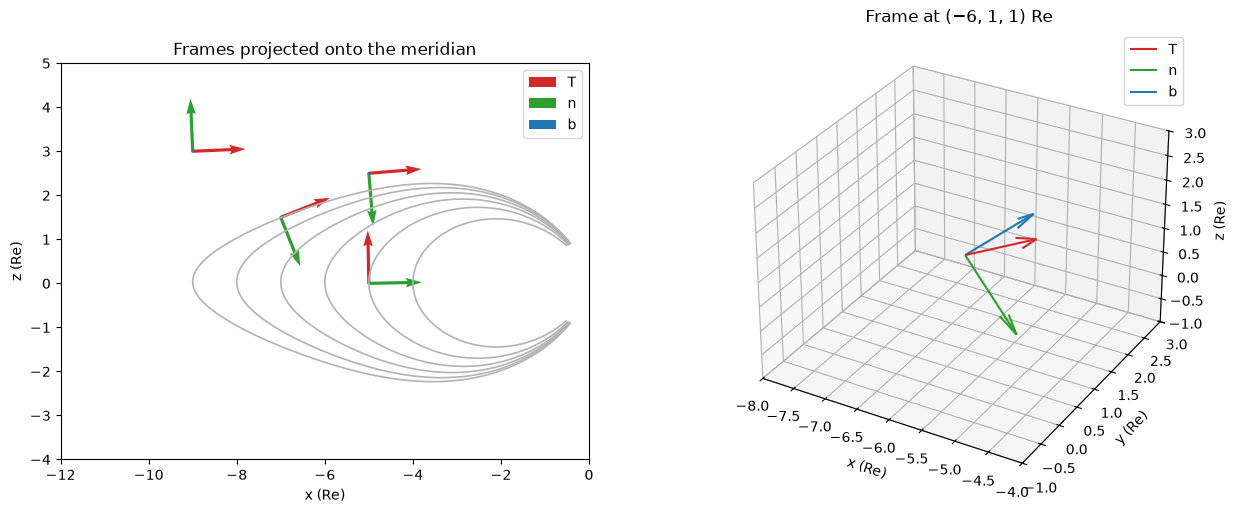

In [8]:
pts_x = np.array([-5.0, -7.0, -9.0, -5.0]); pts_z = np.array([0.0, 1.5, 3.0, 2.5])
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
viz.plot_field_lines(tr, plane="xz", ax=axes[0], color="0.7", unit="Re")
viz.plot_frenet_frame(field, pts_x, np.zeros_like(pts_x), pts_z, ax=axes[0], length=1.2, unit="Re")
axes[0].set_xlim(-12, 0); axes[0].set_ylim(-4, 5)
axes[0].set_title("Frames projected onto the meridian")

ax3 = fig.add_subplot(122, projection="3d"); axes[1].remove()
viz.plot_frenet_frame(field, -6.0, 1.0, 1.0, ax=ax3, length=1.5, unit="Re")
ax3.set_xlim(-8, -4); ax3.set_ylim(-1, 3); ax3.set_zlim(-1, 3)
ax3.set_title("Frame at (−6, 1, 1) Re")
plt.show()

<a id="compose"></a>
## 6. Composing figures and custom quantities

Everything returns matplotlib objects and accepts an existing `ax`, so plots compose freely. A quantity can be any callable `quantity(field, x, y, z)` — here the radius of curvature and the ratio of parallel to perpendicular scale lengths — and `plane_grid` gives you the sampling points if you want to draw something the library does not.

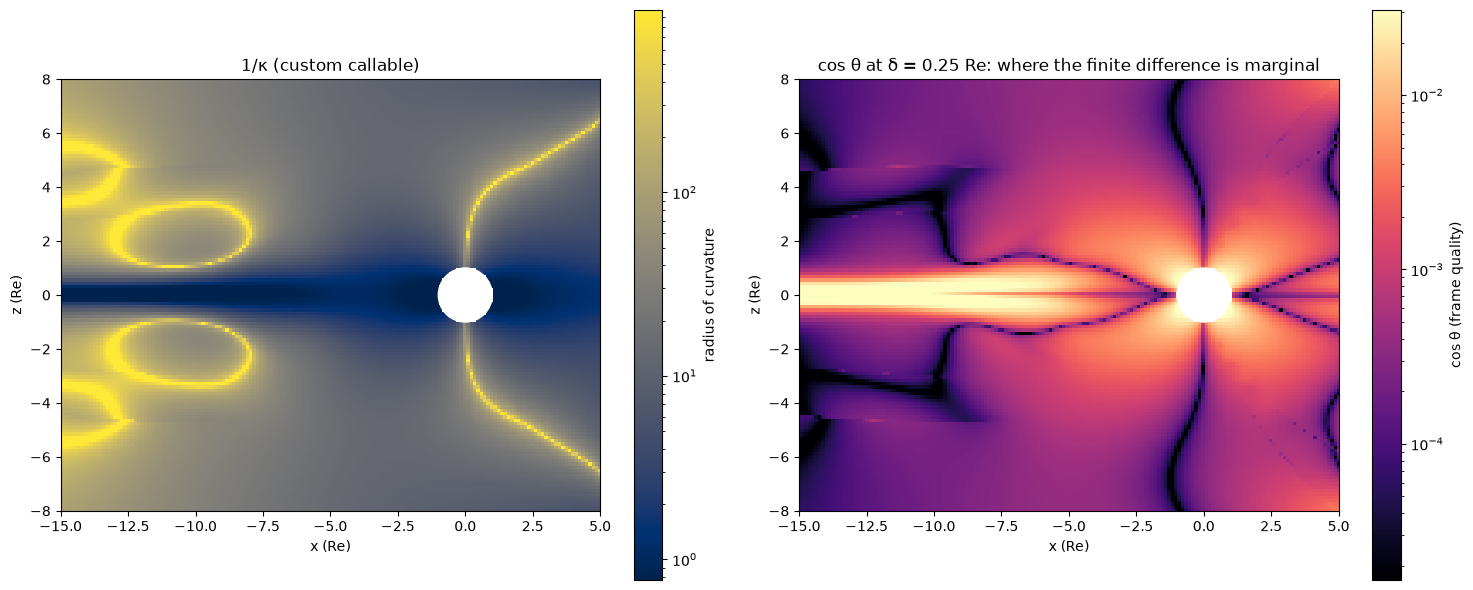

In [9]:
from mageometry import field_line_curvature, field_line_frame_quality

radius = lambda f, x, y, z: 1.0 / field_line_curvature(f, x, y, z, delta=0.01)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
m = viz.plot_geometry_map(field, radius, plane="xz", extent=(-15, 5, -8, 8), n=(160, 130), mask=earth,
                          ax=axes[0], label="radius of curvature", log=True, cmap="cividis", unit="Re")
viz.plot_geometry_map(field, "frame_quality", plane="xz", extent=(-15, 5, -8, 8), n=(160, 130), mask=earth,
                      delta=0.25, ax=axes[1], unit="Re")
axes[0].set_title("1/κ (custom callable)")
axes[1].set_title("cos θ at δ = 0.25 Re: where the finite difference is marginal")
for ax in axes:
    ax.add_patch(plt.Circle((0, 0), 1, color="white", zorder=10))
plt.tight_layout()
plt.show()

<a id="simdata"></a>
## 7. The same plots on simulation data

A `GriddedField` is just another field callable. Here a T96 field is sampled on a coarse grid (as if read from a file — see notebook 08) and the identical calls produce the maps and lines; `bounds=grid.bounds` stops traced lines at the data box.

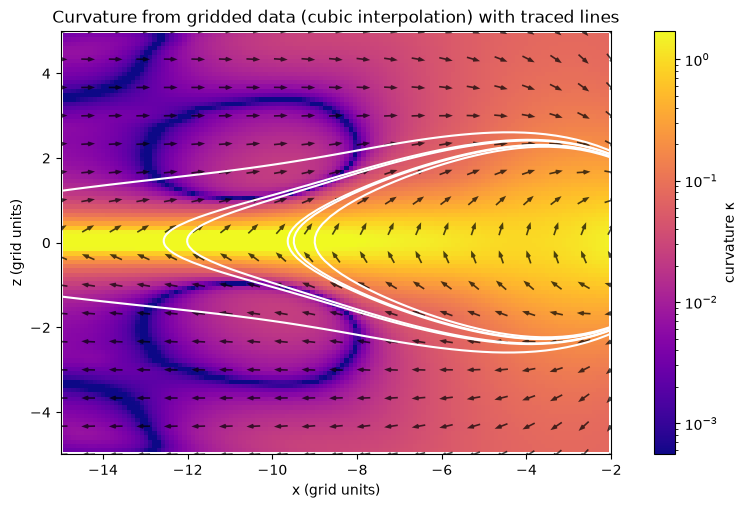

In [10]:
dx = 0.25
xa = np.arange(-15.0, -2.0 + dx / 2, dx); ya = np.arange(-6.0, 6.0 + dx / 2, dx); za = np.arange(-5.0, 5.0 + dx / 2, dx)
X, Y, Z = np.meshgrid(xa, ya, za, indexing="ij")
bx, by, bz = (c.reshape(X.shape) for c in field(X.ravel(), Y.ravel(), Z.ravel()))
grid = GriddedField(xa, ya, za, bx, by, bz, metadata={"source": "synthetic T96 sample"})
gfield = grid.field("cubic")

seed_z = np.linspace(-2.0, 2.0, 7)
gtr = trace_field_lines(gfield, np.full_like(seed_z, -9.0), np.zeros_like(seed_z), seed_z,
                        direction="both", ds=dx, bounds=grid.bounds)

fig, ax = plt.subplots(figsize=(11, 5.5))
viz.plot_geometry_map(gfield, "curvature", plane="xz", extent=(-15, -2, -5, 5), n=(130, 100),
                      delta=0.1, ax=ax, unit="grid units", arrows=True)
viz.plot_field_lines(gtr, plane="xz", ax=ax, color="white", linewidth=1.5)
ax.set_title("Curvature from gridded data (cubic interpolation) with traced lines")
plt.show()